In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
import sys
import os
sys.path.append('..')
sys.path.append(os.path.abspath(os.path.join('..', 'magnet-pinn')))
print(sys.path)

['/Library/Frameworks/Python.framework/Versions/3.12/lib/python312.zip', '/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12', '/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/lib-dynload', '', '/Users/mariusbohn/Documents/Studium/MA/ma_bohn/.venv/lib/python3.12/site-packages', '/Users/mariusbohn/Documents/Studium/MA/ma_bohn/magnet-pinn', '..', '/Users/mariusbohn/Documents/Studium/MA/ma_bohn/magnet-pinn']


In [3]:
from magnet_pinn.data.grid import MagnetGridIterator
iterator = MagnetGridIterator(
    "../data/processed/batch_6/grid_voxel_size_4_data_type_float32",
    phase_samples_per_simulation=2,
)

In [11]:
import torch
from torch.utils.data import DataLoader

dl = DataLoader(iterator, batch_size=1, num_workers=2)
item = next(iter(dl))

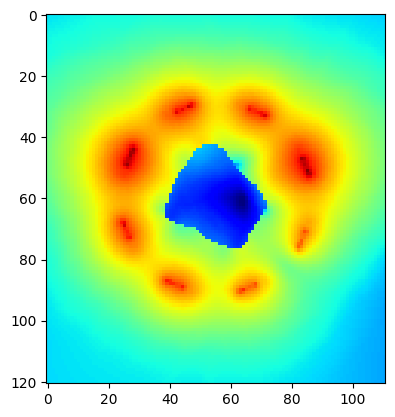

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Ground truth

re = item['field'][0, 0, 0, :, :, :, :]
im = item['field'][0, 0, 1, :, :, :, :]

result = torch.norm(torch.complex(re, im), dim=0)

plt.imshow(result[:, :, 35].cpu().numpy(), cmap='jet', norm='log')
plt.show()

In [ ]:
from mrifield.train.lit_mrifield import LitMRIField
from magnet_pinn.utils import StandardNormalizer
import einops

BASE_DIR = "../data/processed/batch_6/grid_voxel_size_4_data_type_float32"

trained_model = LitMRIField.load_from_checkpoint(
    'lightning_logs/version_2190761/checkpoints/epoch=19-step=3920.ckpt',
    data_path=BASE_DIR
    )
trained_model.eval()

input_normalizer = StandardNormalizer.load_from_json(f"{BASE_DIR}/normalization/input_normalization.json")
inputs = item['input']
coils = item['coils']

x = input_normalizer(torch.cat((inputs, coils), dim=1))

pred = einops.rearrange(trained_model(x), 'b (he reim xyz) ... -> b he reim xyz ...', he=2, reim=2, xyz=3)

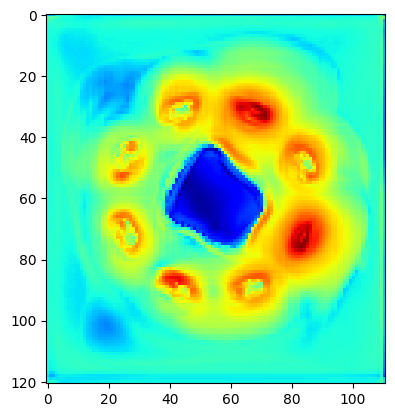

In [14]:
re = pred[0, 0, 0, :, :, :, :]
im = pred[0, 0, 1, :, :, :, :]

result = torch.norm(torch.complex(re, im), dim=0)

plt.imshow(result[:, :, 35].detach().numpy(), cmap='jet', norm='log')
plt.show()

In [ ]:
%reload_ext tensorboard
%tensorboard --logdir=lightning_logs/